<a href="https://colab.research.google.com/github/pyingqi18/ECON5314G/blob/main/CASI_chapter_2_frequentist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2 Frequentist Inference

Frequentist inference evaluates a procedure by imagining how it would behave over repeated samples from the same population. This notebook compares three location estimators for the GFR data and uses the bootstrap to estimate their standard errors.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2.1 A simulation warm-up: what a standard error means

Frequentist accuracy is defined by behaviour over *repeated samples*. An estimate $\hat\theta = t(\vec{x})$ is a single number, but it is one realization of $\hat\Theta = t(\vec{X})$, which takes a range of values as $\vec{X}$ varies over hypothetical data sets drawn from $F$. The standard error is the standard deviation of that range.

With real data we see one sample, and that range stays hypothetical. So before turning to Dr. Myers' patients we work with a population we *choose*. Knowing $F$ lets us reach the same quantity three different ways — by brute-force simulation, by an explicit formula, and by the plug-in estimate we will actually use on real data — and see what each one costs and assumes.

##### A known population

We take $F$ to be a Gamma distribution, right-skewed rather than normal, so that nothing below quietly depends on a bell-shaped population. Its mean $\theta$ and standard deviation $\sigma$ are known exactly, because we chose them.

In [ ]:
from scipy import stats

F0 = stats.gamma(a = 4.0, scale = 5.0)

theta = F0.mean()
sigma = F0.std()
n = 250

print("theta (population mean):", theta)
print("sigma (population sd):  ", sigma)
print("skewness:               ", float(F0.stats("s")))
print("sample size n:          ", n)

theta (population mean): 20.0
sigma (population sd):   10.0
skewness:                1.0
sample size n:           250


##### Repeated samples, repeated estimates

Each row of `X_sim` is one hypothetical data set of size $n$ drawn from $F$, and its mean is one realization of $\hat\Theta$. Listing the first few makes the essential point: the estimate moves from sample to sample, while $\theta$ stays fixed at 20.

In [ ]:
X_sim = F0.rvs(size = (1000, n)) # the larger, closer to the true value, fluctuation will be smalller
X_sim.shape

(1000, 250)

In [ ]:
theta_sim = X_sim.mean(axis = 1)
theta_sim.shape

(1000,)

In [ ]:
theta_sim.std()

np.float64(0.6317181802559514)

In [ ]:
R = 10000
X_sim = F0.rvs(size = (R, n), random_state = np.random.default_rng(2089))

print("X_sim shape:", X_sim.shape)
print()
print("{:<10} {:>10}".format("sample", "xbar"))
print("-" * 21)
for k in range(6):
    print("{:<10} {:>10.3f}".format(k + 1, X_sim[k].mean()))

X_sim shape: (10000, 250)

sample           xbar
---------------------
1              19.906
2              20.775
3              19.696
4              21.176
5              20.271
6              20.850


##### Route 1 --- the standard deviation of $\hat\Theta$ by simulation

Collect all $R$ estimates and take their standard deviation. This carries out the frequentist definition literally: the spread of $\hat\Theta$ across repeated samples.

In [ ]:
theta_sim = X_sim.mean(axis = 1)

se_simulated = theta_sim.std(ddof = 1)
se_simulated

np.float64(0.6355802771319249)

Text(0, 0.5, 'Frequency')

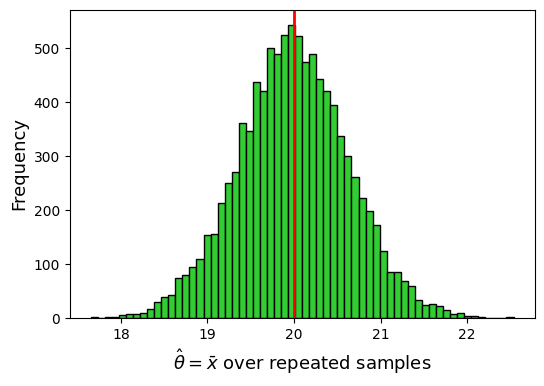

In [ ]:
fig, ax = plt.subplots(figsize = (6,4))
ax.hist(theta_sim, bins = 60, edgecolor = "k", color = "limegreen")
ax.axvline(theta, color = "red", linewidth = 2)
ax.set_xlabel(r"$\hat\theta = \bar{x}$ over repeated samples", size = 13)
ax.set_ylabel("Frequency", size = 13)

##### Route 2 --- the explicit formula

For the sample mean there is a closed-form answer,

$$\mathrm{se}(\bar{X}) = \left[\mathrm{var}_F(X)/n\right]^{1/2} = \sigma/\sqrt{n},$$

which asks only that $F$ have a finite variance — it is not a normality assumption. No simulation is involved.

In [ ]:
se_formula = sigma/np.sqrt(n)
se_formula

np.float64(0.6324555320336759)

##### Route 3 --- the plug-in estimate

Routes 1 and 2 each used something real data will not supply: Route 1 drew fresh samples at will, Route 2 needed $\sigma$. The practical route replaces the unknown $\sigma$ by the standard deviation of the one sample in hand,

$$\widehat{\mathrm{se}} = \hat\sigma/\sqrt{n} = \left[\sum_{i=1}^{n}(x_i - \bar{x})^2 \big/ [n(n-1)]\right]^{1/2}.$$

This is the *plug-in principle*, and it is exactly what Section 2.2 computes for Dr. Myers' patients. Here we can apply it to a single sample and then check the answer against the truth — a check unavailable with real data.

In [ ]:
x_one = X_sim[0]

se_plugin = x_one.std(ddof = 1)/np.sqrt(n)
se_plugin

np.float64(0.6989356697940351)

Unlike Routes 1 and 2, Route 3 changes from sample to sample, because $\hat\sigma$ is itself an estimate. The first six samples give six different answers.

In [ ]:
se_plugin_all = X_sim.std(axis = 1, ddof = 1)/np.sqrt(n)

print("{:<10} {:>10} {:>14}".format("sample", "xbar", "plug-in se"))
print("-" * 36)
for k in range(6):
    print("{:<10} {:>10.3f} {:>14.3f}".format(k + 1, X_sim[k].mean(), se_plugin_all[k]))
print("-" * 36)
print("{:<10} {:>10.3f} {:>14.3f}".format("truth", theta, se_formula))

sample           xbar     plug-in se
------------------------------------
1              19.906          0.699
2              20.775          0.649
3              19.696          0.610
4              21.176          0.642
5              20.271          0.703
6              20.850          0.652
------------------------------------
truth          20.000          0.632


## 2.2 Dr. Myers' nephrology laboratory example

### 2.2.1 Data

The data contain glomerular filtration rate (GFR) measurements for 211 kidney patients. GFR is an indicator of kidney function, with unusually low values suggesting impairment. We treat these observations as a sample from an unknown population distribution $F$.

##### Load and inspect the data

Each row is one observation. Checking the sample size and a few values helps catch path, parsing, or missing-data problems before analysis.

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/data_CASI/gfr.txt", delimiter = " ", header = None, names = ["gfr"])
data.tail()

,gfr
206,28
207,33
208,35
209,48
210,31


##### Estimate the population mean

The sample mean $\hat\theta=\bar{x}$ is the point estimate. Its standard error estimates how much the sample mean would vary across repeated samples of size $n$.

In [ ]:
x = data.gfr

In [ ]:
n = len(x)

In [ ]:
theta_hat = x.mean()
se_hat = np.sqrt(((x - x.mean())**2).sum()/(n*(n-1)))

print(theta_hat, se_hat)

54.2654028436019 0.9445843621716754


##### Visualize the estimate

The histogram shows the distribution's shape, while the red triangle marks the sample mean. The visible right tail helps explain why robust location estimates may differ from the mean.

Text(0, 0.5, 'Frequency')

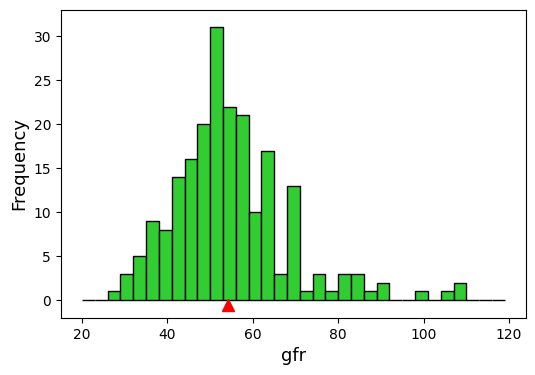

In [ ]:
fig, ax = plt.subplots(figsize = (6,4))
ax.hist(x, bins = np.arange(20, 120, 3), edgecolor = "k", color = "limegreen")
ax.set_ylim(-2, 33)
ax.plot([theta_hat], [-0.6], marker = '^', markersize = 9, color = "red")
ax.set_xlabel("gfr", size = 13)
ax.set_ylabel("Frequency", size = 13)

### 2.2.2 Winsorizing

A 25% Winsorized mean replaces values below the first quartile by that quartile and values above the third quartile by that quartile, then averages the modified data. It reduces sensitivity to extreme observations without discarding them.

In [ ]:
from scipy.stats.mstats import winsorize

In [ ]:
help(winsorize)

Help on function winsorize in module scipy.stats._mstats_basic:

winsorize(
    a,
    limits=None,
    inclusive=(True, True),
    inplace=False,
    axis=None,
    nan_policy='propagate'
)
    Returns a Winsorized version of the input array.

    The (limits[0])th lowest values are set to the (limits[0])th percentile,
    and the (limits[1])th highest values are set to the (1 - limits[1])th
    percentile.
    Masked values are skipped.


    Parameters
    ----------
    a : sequence
        Input array.
    limits : {None, tuple of float}, optional
        Tuple of the percentages to cut on each side of the array, with respect
        to the number of unmasked data, as floats between 0. and 1.
        Noting n the number of unmasked data before trimming, the
        (n*limits[0])th smallest data and the (n*limits[1])th largest data are
        masked, and the total number of unmasked data after trimming
        is n*(1.-sum(limits)) The value of one limit can be set to None to
    

In [ ]:
x

,gfr
0,108
1,91
2,62
3,59
4,84
...,...
206,28
207,33
208,35
209,48


In [ ]:
x_winsor = winsorize(x, limits = [0.025, 0.025])
x_winsor

masked_array(data=[89, 89, 62, 59, 84, 60, 71, 89, 70, 69, 66, 65, 78, 83,
                   82, 68, 89, 68, 68, 69, 80, 75, 89, 68, 64, 68, 70, 57,
                   62, 87, 51, 55, 56, 57, 75, 89, 60, 68, 81, 47, 76, 48,
                   63, 58, 40, 62, 61, 58, 38, 40, 45, 68, 56, 64, 49, 53,
                   50, 39, 54, 47, 37, 50, 54, 70, 49, 57, 52, 47, 43, 52,
                   57, 46, 63, 56, 50, 51, 50, 42, 46, 56, 52, 59, 45, 50,
                   59, 44, 52, 54, 53, 63, 45, 56, 55, 53, 56, 46, 45, 49,
                   63, 50, 41, 42, 53, 50, 58, 50, 37, 53, 58, 49, 53, 51,
                   64, 44, 53, 53, 55, 43, 50, 60, 51, 55, 56, 52, 51, 45,
                   49, 51, 63, 48, 51, 60, 45, 40, 50, 66, 62, 69, 53, 54,
                   49, 47, 63, 55, 62, 57, 58, 51, 50, 57, 62, 45, 47, 52,
                   35, 41, 53, 48, 59, 45, 41, 52, 36, 84, 62, 33, 41, 48,
                   47, 50, 50, 57, 53, 37, 46, 41, 56, 51, 39, 59, 53, 51,
                   49, 45

Text(0, 0.5, 'Frequency')

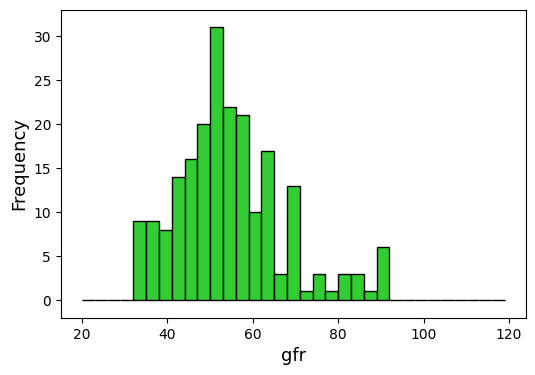

In [ ]:
fig, ax = plt.subplots(figsize = (6,4))
ax.hist(x_winsor, bins = np.arange(20, 120, 3), edgecolor = "k", color = "limegreen")
ax.set_ylim(-2, 33)
# ax.plot([theta_hat], [-0.6], marker = '^', markersize = 9, color = "red")
ax.set_xlabel("gfr", size = 13)
ax.set_ylabel("Frequency", size = 13)

In [ ]:
x_winsor.mean()

np.float64(54.018957345971565)

## 2.3 Frequentism in Practice

The mean has a familiar analytic standard-error formula. For the median and Winsorized mean, the bootstrap provides a common computational route to the same inferential goal.

#### Bootstrap standard errors for location estimators

A bootstrap sample draws $n$ observations with replacement from the observed data, treating the empirical distribution $\hat F$ as a stand-in for the unknown $F$. Repeating the complete estimation procedure approximates its sampling distribution.

In [ ]:
x.sample(1) # give one observation from random sampling

,gfr
134,50


In [ ]:
help(x.sample)

Help on method sample in module pandas.core.generic:

sample(
    n: 'int | None' = None,
    frac: 'float | None' = None,
    replace: 'bool_t' = False,
    weights=None,
    random_state: 'RandomState | None' = None,
    axis: 'Axis | None' = None,
    ignore_index: 'bool_t' = False
) -> 'Self' method of pandas.core.series.Series instance
    Return a random sample of items from an axis of object.

    You can use `random_state` for reproducibility.

    Parameters
    ----------
    n : int, optional
        Number of items from axis to return. Cannot be used with `frac`.
        Default = 1 if `frac` = None.
    frac : float, optional
        Fraction of axis items to return. Cannot be used with `n`.
    replace : bool, default False
        Allow or disallow sampling of the same row more than once.
    weights : str or ndarray-like, optional
        Default 'None' results in equal probability weighting.
        If passed a Series, will align with target object on index. Index
    

In [ ]:
x.sample(20, replace = True) #replace : bool, default False   Allow or disallow sampling of the same row more than once.
# Equivalent: histogram as non_paramatric F_hat to estimate F

,gfr
123,52
146,58
90,45
63,70
98,63
115,53
84,59
75,51
189,35
163,84


In [ ]:
x_boot = x.sample(n, replace = True)

np.float64(52.63507109004739)

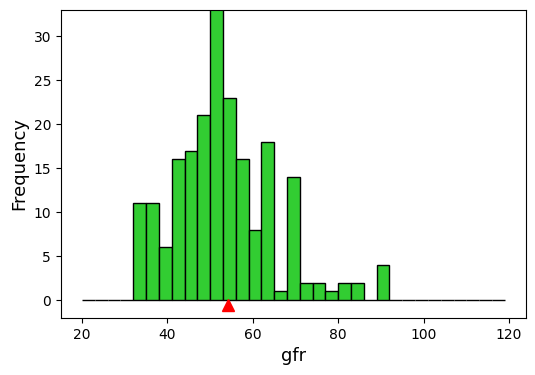

In [ ]:
fig, ax = plt.subplots(figsize = (6,4))
ax.hist(x_boot, bins = np.arange(20, 120, 3), edgecolor = "k", color = "limegreen")
ax.set_ylim(-2, 33)
ax.plot([theta_hat], [-0.6], marker = '^', markersize = 9, color = "red")
ax.set_xlabel("gfr", size = 13)
ax.set_ylabel("Frequency", size = 13)

x_boot.mean() # everytime a different theta_hat

In [ ]:
# 上面的x_boot是一个单独的自举样本，重复多次自举抽样，每次计算一个theta_hat, 最后计算这些theta_hat的标准差
B = 2000
rng = np.random.default_rng(2026)

theta_hats_avg = np.zeros(B)
theta_hats_med = np.zeros(B)
theta_hats_win = np.zeros(B)

for i in range(B):
    x_boot = x.sample(n, replace = True, random_state = rng)
    theta_hats_avg[i] = np.mean(x_boot)
    theta_hats_med[i] = np.median(x_boot)
    theta_hats_win[i] = np.mean(winsorize(x_boot, limits = [0.25, 0.25]))

# [theta_hats_avg.mean(), theta_hats_avg.std()]
# [theta_hats_med.mean(), theta_hats_med.std()]
# [theta_hats_win.mean(), theta_hats_win.std()]

In [ ]:
# Bootstrap SE of the 25% Winsorized mean
theta_hats_win.std(ddof = 1)

np.float64(0.9050786951980659)

In [ ]:
estimate_win = np.mean(x_winsor)
se_win = theta_hats_win.std(ddof = 1)
estimate_med = np.median(x)
se_med = theta_hats_med.std(ddof = 1)

In [ ]:
tmplt = "{:<20}  {:>0.2f}  {:>0.2f}"
print("                   Estimate    SE")
print("-" * 35)
print(tmplt.format("mean", theta_hat, se_hat))
print(tmplt.format("Winsorized mean", estimate_win, se_win))
print(tmplt.format("median", estimate_med, se_med))
# outlier会影响，more robust，se越小

                   Estimate    SE
-----------------------------------
mean                  54.27  0.94
Winsorized mean       54.02  0.91
median                52.00  0.87


Recall: compare the se by bootstarp and formula

In [ ]:
theta_hat = x.mean()
se_hat = np.sqrt(((x - x.mean())**2).sum()/(n*(n-1)))

print(theta_hat, se_hat)

54.2654028436019 0.9445843621716754


### Interpretation

The point estimates are computed from the original sample; bootstrap replicates are used only to estimate uncertainty. Differences among the mean, Winsorized mean, and median reflect sensitivity to the right tail. Similar standard errors do not make the estimators interchangeable: they target location with different robustness trade-offs.

The bundled `gfr.txt` values are rounded to integers, so these estimates need not exactly match the more precise values reported in the book's Table 2.1.